# Secondary Loan Market Simulation Explanatory Notebook


### The Loan Class

In [1]:
import numpy as np
import uuid
import matplotlib.pyplot as plt
import time

In [2]:
class Loan:
    """
    Represents a loan in the simulation.
    
    Attributes:
        id (str): Unique identifier for the loan.
        maturity (int): Number of cycles until the loan matures.
        current_cycle (int): The current cycle of the simulation.
        starting_cycle (int): The cycle when the loan was initiated.
        ending_cycle (int): The cycle when the loan will end.
        time_to_maturity (int): Number of cycles until the loan matures.
        pd (float): Probability of default for the loan.
        size (float): Size of the loan.
        interest_rate (float): Interest rate of the loan.
        fair_value (float): Fair value of the loan.
        market_price (float): Market price of the loan.
        current_owner (str): The current owner of the loan.
        maturity_bool (bool): Indicates if the loan has matured.
        fair_value_history (list): History of the loan's fair values.
        market_price_history (list): History of the loan's market prices.
        ownership_history (list): History of the loan's ownership.
    """
    
    __slots__ = ['id', 'maturity', 'current_cycle', 'starting_cycle', 'ending_cycle', 'time_to_maturity', 'pd', 'size', 'interest_rate', 'fair_value', 'market_price', 'current_owner', 'maturity_bool', 'fair_value_history', 'market_price_history', 'ownership_history'] 
    
    def __init__(self, current_cycle=0, current_owner="no owner"):
        """
        Initializes the Loan with random values for maturity, pd, size, interest rate, and fair value.
        Sets the starting cycle, calculates the ending cycle and time to maturity based on maturity.
        Initializes histories and sets the current owner.
        """
        
        self.id = str(uuid.uuid4())
        self.maturity = np.random.randint(3, 8)
        self.current_cycle = current_cycle
        self.starting_cycle = self.current_cycle
        self.ending_cycle = self.starting_cycle + self.maturity
        self.time_to_maturity = self.ending_cycle - self.current_cycle  # Consider calculating this on the fly
        self.pd = np.random.beta(1, 50)
        self.size = np.random.uniform(500_000, 5_000_000)
        self.interest_rate = self.generate_interest_rate()
        self.fair_value = self.calculate_price()
        self.market_price = self.fair_value
        self.current_owner = current_owner
        self.maturity_bool = False
        
        # tracking attributes
        self.fair_value_history = []
        self.market_price_history = []
        self.ownership_history = [current_owner]

    def generate_interest_rate(self):
        """
        Generates a random interest rate based on some factors and noise.
        The interest rate is influenced by the loan's probability of default.
        """
        
        base_level_noise = np.random.normal(0.02, 0.005)
        correlation_factor = 0.8
        influence_factor = np.random.uniform(0.05, 0.15)
        correlated_component = correlation_factor * self.pd * influence_factor
        return base_level_noise + correlated_component

    def calculate_price(self):
        """
        Calculates the price of the loan based on its attributes.
        The price is influenced by the probability of default, interest rate, and size.
        """
        
        pd_effect = -7 * self.pd if self.pd <= 0.2 else -14 * self.pd  
        ir_effect = 5 * self.interest_rate
        size_effect = -0.0000002 * self.size
        return 100 + pd_effect + ir_effect + size_effect
    
    @staticmethod
    def generate():
        return Loan()
    
    def update_owner(self, new_owner):
        self.current_owner = new_owner
        self.ownership_history.append(new_owner)
        
    
    def update(self, current_cycle, new_owner = None, new_market_price=None):
        """
        Updates the loan's attributes for a new cycle.
        If the loan has matured, checks for default and adjusts fair value and market price accordingly.
        Records the changes in the histories.
        
        Args:
        current_cycle (int): The new current cycle.
        new_owner (str, optional): The new owner of the loan, if it has changed.
        new_market_price (float, optional): The new market price of the loan, if it has changed.
        """

        if current_cycle > self.ending_cycle:
            return
        
        if new_owner:
            self.update_owner(new_owner)
        
        self.current_cycle = current_cycle
        self.time_to_maturity = self.ending_cycle - self.current_cycle
        self.fair_value = self.calculate_price()
        
        if new_market_price:
            self.market_price = new_market_price
        self.market_price_history.append(self.market_price)
        
        # Loan maturity logic
        if current_cycle == self.ending_cycle:
            self.maturity_bool = True
            default_outcome = np.random.rand() < self.pd
            if default_outcome:
                self.fair_value = np.random.normal(10, 2)
                self.market_price = self.fair_value  # Set to liquidation value
            else:
                self.fair_value = 100  # Set to par value
                self.market_price = 100  # Set to par value
        self.fair_value_history.append(self.fair_value)
    
    

In [3]:
class LoanInvestor:
    def __init__(self, trader=None, capital=None):
        self.id = 'I'+str(uuid.uuid4())
        self.capital = capital if capital else self.generate_initial_capital()
        self.capital_history = []
        self.target_score = np.abs(np.random.normal(1.0, 0.2))
        self.loan_fair_values = []
        self.portfolio_values = []
        self.portfolio = []
        self.matured_loans = []
        self.current_score = 0
        self.trader = trader
        self.interest_received = []
    
    def generate_initial_capital(self):
        random_capital = np.round((np.random.pareto(2, 1) + 1)*50*1000000, 0)[0]
        return random_capital
    
    def initialize_portfolio(self, available_loans, capital_threshold=0.9):
        
        """
        Initializes the investor's portfolio with available loans.
        :param available_loans: List of available loans already prepared by the loanMarket class.
        :param capital_threshold: Maximum proportion of capital to be invested.
        """
        
        np.random.shuffle(available_loans)
        total_investment = 0
        for loan in available_loans:
            purchase_value = (loan.market_price/100) * loan.size
            if total_investment + purchase_value <= self.capital*capital_threshold:
                total_investment += purchase_value
                loan.update_owner(self.id)
                self.portfolio.append(loan)
            else:
                break
        
        self.capital -= total_investment
        self.calculate_current_score()
        self.loan_fair_values.append(np.sum([(loan.fair_value * (loan.size/100)) for loan in self.portfolio]))
        self.portfolio_values.append(self.loan_fair_values[-1] + self.capital)
        self.capital_history.append(self.capital)
        
    def calculate_value(self):
        self.loan_fair_values.append(np.sum([((loan.fair_value/100) * loan.size) for loan in self.portfolio]))
        self.portfolio_values.append(self.loan_fair_values[-1] + self.capital)
        self.capital_history.append(self.capital)
        
    def calculate_current_score(self):
        weighted_interest = sum([loan.interest_rate * loan.size for loan in self.portfolio])
        weighted_pd = sum([loan.pd * loan.size for loan in self.portfolio])
        total_size = sum([loan.size for loan in self.portfolio])
        self.current_score = (weighted_interest / total_size) / (weighted_pd / total_size) if weighted_interest > 0 else 0
        
    def get_loans_to_sell(self):
        return
    
    def get_bid_price(self, loan):
        return
    
    def receive_interest(self, float_interest = 0):
        '''
        This is the procedure every cycle for the investor to receive interest on their loans. 
        :param float_interest: The floating base rate for interest (think SOFR)
        '''
        total_interest = 0
        for loan in self.portfolio:
            if loan.maturity_bool==True:
                self.capital += (loan.fair_value/100) * loan.size
                self.matured_loans.append(loan)
                self.portfolio.remove(loan)
            else:
                total_interest += loan.size * (loan.interest_rate + float_interest)
                
        self.capital += total_interest
        self.interest_received.append(total_interest)
        
    def update(self, float_interest = 0):
        self.receive_interest(float_interest)
        self.calculate_value()
        self.calculate_current_score()

In [4]:
class trader:
    def __init__(self, max_investors = 10):
        self.id = 'T'+str(uuid.uuid4())
        self.max_investors = max_investors
        self.max_investors_reached = False
        self.loans_for_sale = []
        self.investors = []
    
    def add_investor(self, investors):
        for investor in investors:
            if investor.trader == None and len(self.investors) < self.max_investors:
                self.investors.append(investor)
                investor.trader = self
            else:
                self.max_investors_reached = True
                pass
            
    def initialize_book(self, available_loans):
        self.loans_for_sale.append(available_loans)
        for loan in available_loans:
            loan.update_owner(self.id)
    
    def run_auction(self):
        return

In [5]:
class loanMarket:
    def __init__(self, num_loans, num_investors, num_traders):
        
        self.cycle = 0
        self.num_loans = num_loans
        self.num_investors = num_investors
        self.num_traders = num_traders
        
        # creating the universe of loans
        self.loans = [Loan() for _ in range(self.num_loans)]
        
        # creating the universe of investors
        self.investors = [LoanInvestor() for _ in range(self.num_investors)]
        
        # creating the universe of traders
        self.traders = [trader(max_investors = self.num_investors//self.num_traders) for _ in range(self.num_traders)]
        
    
    def initialize(self):
        
        for investor in self.investors:
            # regenerating list of available loans
            available_loans = [loan for loan in self.loans if loan.current_owner == "no owner"]
            investor.initialize_portfolio(available_loans)
        
        # Assign unsold loans to traders
        unsold_loans = [loan for loan in self.loans if loan.current_owner == "no owner"]
        unsold_loans_count = len(unsold_loans)
        loans_per_trader = unsold_loans_count // self.num_traders

        for trader_ in self.traders:
            trader_loans = unsold_loans[:loans_per_trader]
            unsold_loans = unsold_loans[loans_per_trader:]  # Update the unsold_loans list
            trader_.initialize_book(trader_loans)
            
            # Assign investors to the trader if they haven't reached their maximum
            if not trader_.max_investors_reached:
                trader_.add_investor(self.investors)
        
        # If there are any leftover loans, assign them randomly to the traders
        for loan in unsold_loans:
            trader = np.random.choice(self.traders)
            loan.update_owner(trader.id)
            trader.loans_for_sale.append(loan)

        # Assign any unassigned investors to traders randomly
        unassigned_investors = [investor for investor in self.investors if investor.trader is None]
        for investor in unassigned_investors:
            trader = np.random.choice(self.traders)
            trader.investors.append(investor)
            investor.trader = trader
            
    def update(self):
        for loan in self.loans:
            # loans are updated independent of investors
            loan.update(self.cycle+1)
        for investor in self.investors:
            # investors are updated based on the loans they hold
            investor.update()
        
        self.cycle += 1
        
    def get_average_portfolio_values(self):
        # Calculate the average portfolio value at the end of each cycle
        avg_portfolio_values = []
        for cycle in range(self.cycle):
            cycle_values = [investor.portfolio_values[cycle] for investor in self.investors if investor.portfolio_values]
            avg_value = sum(cycle_values) / len(cycle_values) if cycle_values else 0
            avg_portfolio_values.append(avg_value)
        return avg_portfolio_values
      

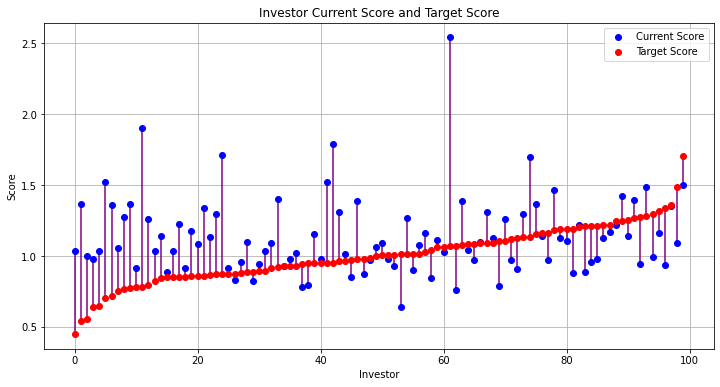

In [6]:
# plotting out the target vs current score for all the investors in the loan market

market = loanMarket(num_loans=10000, num_investors=100, num_traders=10)
market.initialize()

# Sorting the scores for a more organized visualization
current_scores = np.array([investor.current_score for investor in market.investors])
target_scores= np.array([investor.target_score for investor in market.investors])

# Sorting the scores for a more organized visualization
indices = np.argsort(target_scores)
current_scores_sorted = current_scores[indices]
target_scores_sorted = target_scores[indices]

# Creating a scatter plot with connected lines
plt.figure(figsize=(12, 6))
for i in range(market.num_investors):
    plt.plot([i, i], [current_scores_sorted[i], target_scores_sorted[i]], color='purple')  # lines
plt.scatter(range(market.num_investors), current_scores_sorted, color='blue', label='Current Score', zorder=5)
plt.scatter(range(market.num_investors), target_scores_sorted, color='red', label='Target Score', zorder=5)

plt.ylabel("Score")
plt.xlabel("Investor")
plt.title("Investor Current Score and Target Score")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
loan_Market = loanMarket(100000, 122, 80)

In [8]:
loan_Market.initialize()

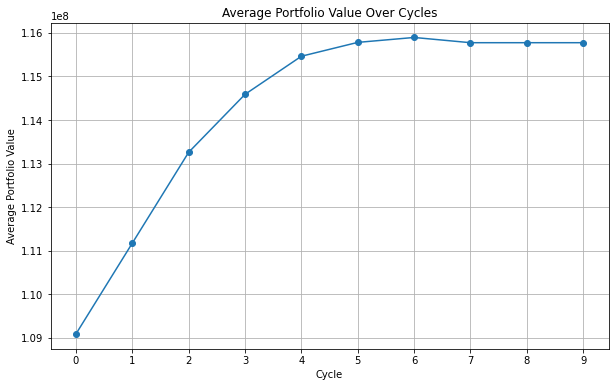

In [9]:
for _ in range(10):
    loan_Market.update()
    
    
average_portfolio_values = loan_Market.get_average_portfolio_values()

# Visualizing the average portfolio values
plt.figure(figsize=(10, 6))
plt.plot(average_portfolio_values, marker='o')
plt.title('Average Portfolio Value Over Cycles')
plt.xlabel('Cycle')
plt.ylabel('Average Portfolio Value')
plt.xticks(range(10))
plt.grid(True)
plt.show()